# Partial Differential Equation

Consider the one-dimensional heat equation with homogeneous Dirichlet boundary conditions
$$
\begin{aligned}
u_t & =u_{x x}, & & x \in(0,1), t>0, \\
u(0, t) & =0, & & t>0, \\
u(1, t) & =0, & & t>0, \\
u(x, 0) & =u_0(x), & & x \in(0,1) .
\end{aligned}
$$
In this problem, you will discretize the spatial derivative with the standard central difference formula and investigate the behavior of different time stepping methods. Include the code, written in your choice of language, with your submission.

When discretizing the spatial derivative with the second-order centered difference formula, the result is the sparse $N \times N$ matrix
$$
L=\left[\begin{array}{cccccc}
-2 & 1 & & & & \\
1 & -2 & 1 & & & \\
& 1 & -2 & 1 & & \\
& & \ddots & \ddots & \ddots & \\
& & & 1 & -2 & 1 \\
& & & & 1 & -2
\end{array}\right] 
$$

PART 1: Use a sparse library package to generate the matrix $L$. The only input should be the size of the matrix $N .(20 points)
   

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags 
import math
from scipy.sparse.linalg import spsolve

def generate_tridiagonal_matrix(N):
    main_diagonal = -2*np.ones(N)
    lower_diagonal = np.ones(N-1)
    upper_diagonal = np.ones(N-1)
    
    matrix = diags([lower_diagonal, main_diagonal, upper_diagonal], [-1, 0, 1], shape=(N,N), format='csr')  
    
    return matrix 

L = generate_tridiagonal_matrix(5)
print(L.toarray())



[[-2.  1.  0.  0.  0.]
 [ 1. -2.  1.  0.  0.]
 [ 0.  1. -2.  1.  0.]
 [ 0.  0.  1. -2.  1.]
 [ 0.  0.  0.  1. -2.]]


Part 2: Consider discretizing the domain $(0,1)$ at $N$ equispaced interior points. That is, $(0,1)$ is discretized at $\Delta x, 2 \Delta x, \ldots, N \Delta x$, where $\Delta x=1 /(N+1)$. Because of the homogeneous boundary conditions, the spatial derivative at the discretization points can be approximated as $\frac{1}{\Delta x^2} L \mathbf{u}$, where $\mathbf{u} \in \mathbf{R}^N$ is any function discretized at the points mentioned above. Perform a convergence study to show that $\frac{1}{\Delta x^2} L$ is second-order accurate. Use the function $u(x)=\sin (\pi x)$, the resolution $\Delta x=\frac{1}{8}, \frac{1}{16}, \ldots, \frac{1}{512}$, and the infinity norm to compare the approximate and exact solutions. (30 points)

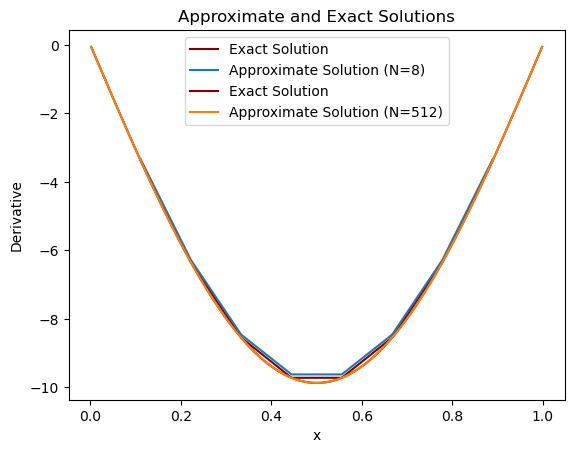

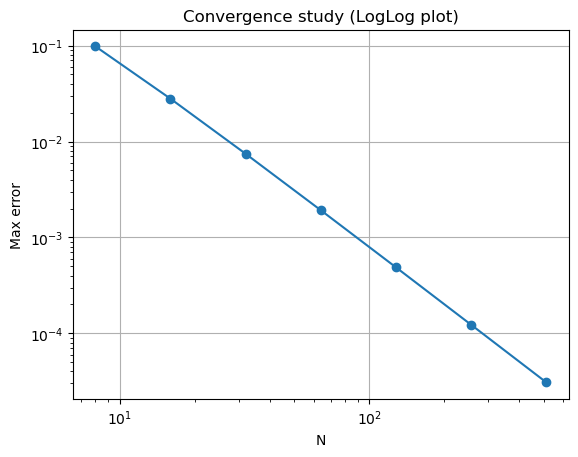

In [57]:
# defining the function u
def u_exact(x):
    return np.sin(np.pi*x)

def du_exact(x):
    return -np.pi*np.pi*np.sin(np.pi*x)
    
    
def calculate_error(N):
    dx = 1 / (N + 1)
    
    # Discretizing the space
    x = np.linspace(dx, 1 - dx, N)
    u = u_exact(x)
    
    L = generate_tridiagonal_matrix(N)
    du_approx = L.dot(u) / (dx**2)
    du = -np.pi**2 * u_exact(x)
    
    if N==8 or N==512:
        plt.plot(x, du, 'maroon', label='Exact Solution')
        plt.plot(x, du_approx, label='Approximate Solution (N={})'.format(N))
        plt.xlabel('x')
        plt.ylabel('Derivative')
        plt.title('Approximate and Exact Solutions')
        plt.legend()
    
    # Calculate infinite norm
    error = np.abs(du - du_approx)
    max_error = np.max(error)
    
    return max_error

resolutions = [2**i for i in range(3,10)]
errors=[]

for N in resolutions:
    error_N = calculate_error(N)
    errors.append(error_N)

#plotting and convergence study
plt.figure()
plt.loglog(resolutions, errors, marker = 'o')
plt.xlabel("N")
plt.ylabel("Max error")
plt.title("Convergence study (LogLog plot)")
plt.grid(True)
plt.show()   
 
    



Apply these three methods to the heat equation with $\Delta x=0.01(N=99), \Delta t=0.01$, 100 time steps, and the initial condition $u_0(x)=\sin (\pi x)$. Described what you observe and relate these observations to concepts you have learnt about stability. (20 points)

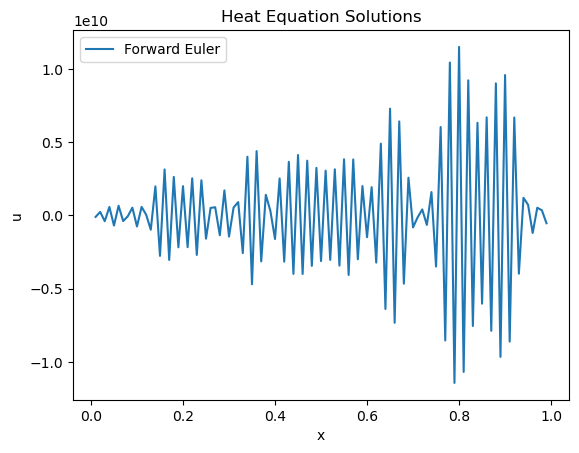

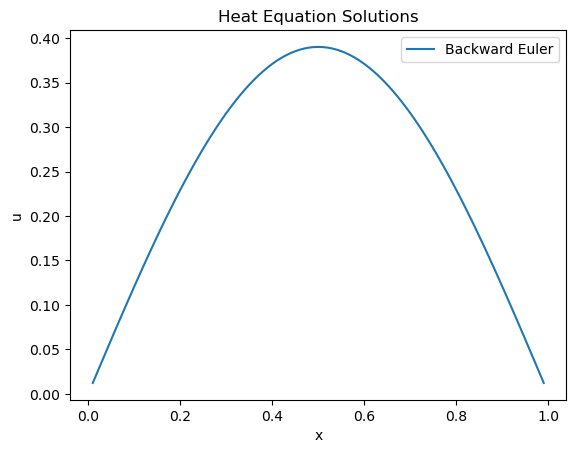

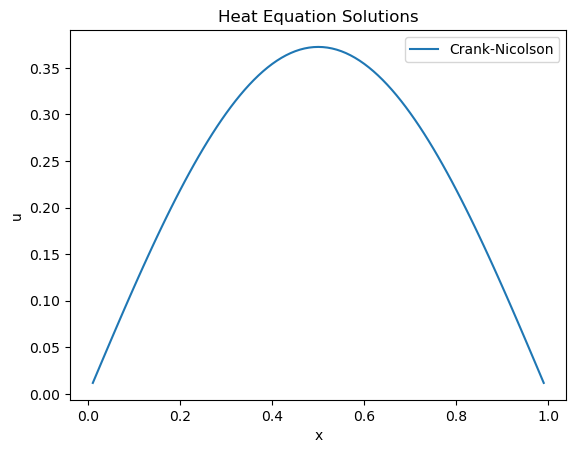

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags

def generate_tridiagonal_matrix(N):
    main_diagonal = -2 * np.ones(N)
    lower_diagonal = np.ones(N - 1)
    upper_diagonal = np.ones(N - 1)

    matrix = diags([lower_diagonal, main_diagonal, upper_diagonal], [-1, 0, 1], shape=(N, N), format='csr')

    return matrix


def Heat_eq(N):
    dx = 1 / (N + 1)
    x = np.linspace(dx, 1 - dx, N)
    dt = 0.01
    steps = 10
    L = generate_tridiagonal_matrix(N)

    A_FE = np.eye(N) + (dt / (dx * dx)) * L
    A_BE = np.linalg.inv(np.eye(N) - (dt / (dx * dx)) * L)
    A_CN = np.linalg.inv(np.eye(N) - (dt / (2 * dx * dx)) * L) * (np.eye(N) + (dt / (2 * dx * dx)) * L)

    # Set initial condition
    u_init = np.sin(np.pi*x)
    u_init = u_init.reshape(-1, 1)  # Reshape to column vector

    methods = {
        "Forward Euler": A_FE,
        "Backward Euler": A_BE,
        "Crank-Nicolson": A_CN
    }

    for method, A in methods.items():
        u = u_init
        for _ in range(steps):
            u = A.dot(u)

        plt.plot(x, u, label=method)
        #plt.plot(x,np.sin(np.pi*x))
        plt.xlabel('x')
        plt.ylabel('u')
        plt.title('Heat Equation Solutions')
        plt.legend()
        plt.show()


N = 99
Heat_eq(N)


Apply these three methods to the heat equation with $\Delta x=0.01(N=99), \Delta t=0.01$, 100 time steps, and the initial condition}
    $$
    u_0(x)= \begin{cases}1 & x \in(0.25,0.75) \\ 0 & x \notin(0.25,0.75)\end{cases}
    $$
Contrast what you observe and what you observed in part d. 

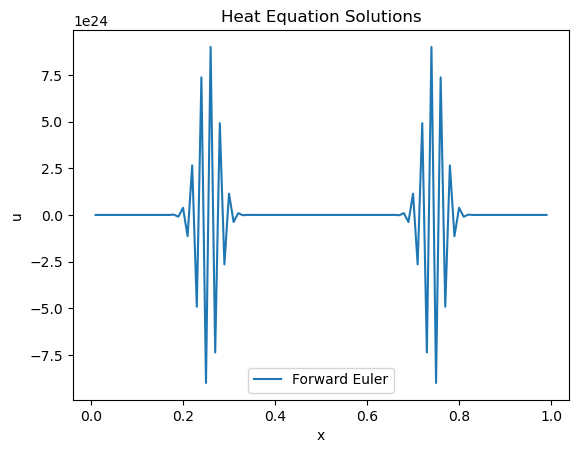

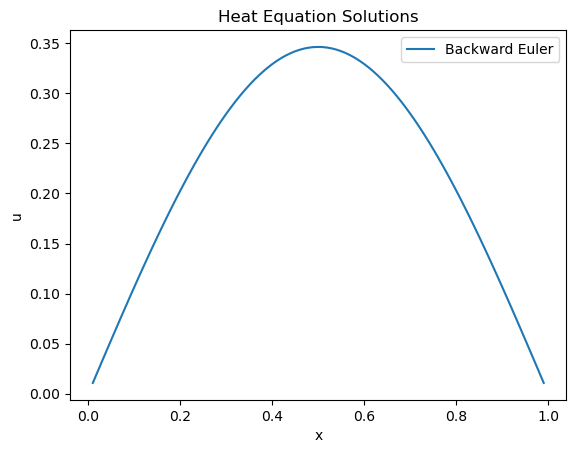

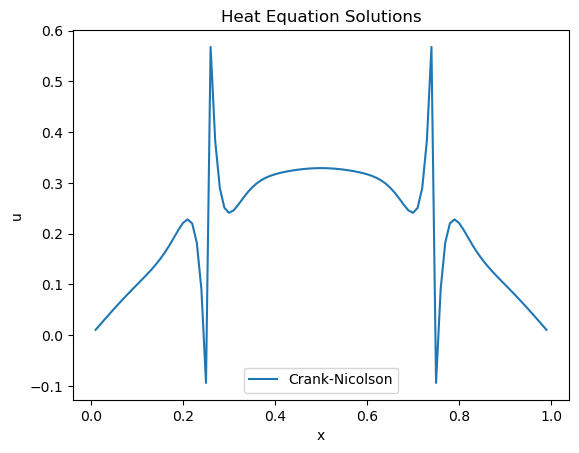

In [72]:
def u_exact(x):
    return np.where((x > 0.25) & (x < 0.75), 1, 0)

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags

def generate_tridiagonal_matrix(N):
    main_diagonal = -2 * np.ones(N)
    lower_diagonal = np.ones(N - 1)
    upper_diagonal = np.ones(N - 1)

    matrix = diags([lower_diagonal, main_diagonal, upper_diagonal], [-1, 0, 1], shape=(N, N), format='csr')

    return matrix


def Heat_eq(N):
    dx = 1 / (N + 1)
    x = np.linspace(dx, 1 - dx, N)
    dt = 0.01
    steps = 10
    L = generate_tridiagonal_matrix(N)

    A_FE = np.eye(N) + (dt / (dx * dx)) * L
    A_BE = np.linalg.inv(np.eye(N) - (dt / (dx * dx)) * L)
    A_CN = np.linalg.inv(np.eye(N) - (dt / (2 * dx * dx)) * L) * (np.eye(N) + (dt / (2 * dx * dx)) * L)

    # Set initial condition
    u_init = u_exact(x)
    u_init = u_init.reshape(-1, 1)  # Reshape to column vector

    methods = {
        "Forward Euler": A_FE,
        "Backward Euler": A_BE,
        "Crank-Nicolson": A_CN
    }

    for method, A in methods.items():
        u = u_init
        for _ in range(steps):
            u = A.dot(u)

        plt.plot(x, u, label=method)
        #plt.plot(x,np.sin(np.pi*x))
        plt.xlabel('x')
        plt.ylabel('u')
        plt.title('Heat Equation Solutions')
        plt.legend()
        plt.show()


N = 99
Heat_eq(N)



# LINEAR ALGEBRA

Given a matrix $A \in \mathbf{R}^{N \times N}$, a common task is to find an orthogonal matrix $Q \in \mathbf{R}^{N \times l}$ such that the range of $Q$ is as close as possible to the range of $A$. Here you will consider a randomized method to generate such a matrix $Q$ when $A$ is a low rank matrix. Include the code, written in your choice of language, with your submission.

Given two sets of points $X=\left\{x_1, x_2, \ldots, x_N\right\} \subset \mathbf{R}^d$ and $Y=\left\{y_1, y_2, \ldots, y_N\right\} \subset \mathbf{R}^d$, and a kernel $K: \mathbf{R}^d \times \mathbf{R}^d \rightarrow \mathbf{R}$, consider the matrix $A \in \mathbf{R}^{N \times N}$ whose $(i, j)$ entry is
    $$
    a_{i, j}=K\left(x_i, y_j\right)
    $$
    Write a code that generates such a random matrix $A$. Choose the points in $X$ from the uniform distribution $U(0,1)^d$ and $Y$ from the uniform distribution $y_0+U(0,1)^d$, where the dimension $d$ and the center $y_0$ are inputs into your function. Use the kernel function
    $$
    K(x, y)=log |x-y| 
    $$

Using $d=4, N=200$, and $y_0=(10,2,1,3)$, generate a random matrix $A$ described in part a and plot its singular values on a semilogy axis.

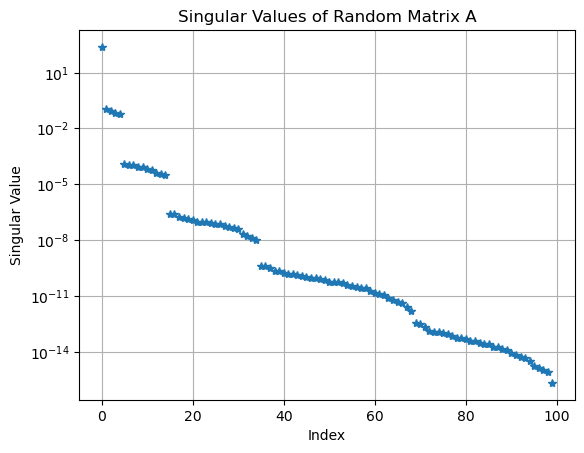

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random 

def generate_matrix(X, Y, y0, d):
    N = len(X)
    A = np.zeros((N, N))
    
    for i in range(N):
        for j in range(N):
            xi = X[i]
            yj = Y[j]
            
            distance = np.linalg.norm(xi - yj)
            A[i, j] = np.log(distance)
    
    return A    

# Example usage
d = 4  # Dimension of points
y0 = np.array([10, 2, 1, 3])  # Center of Y
N = 100
# Generate X and Y from uniform distributions
np.random.seed(42)  # For reproducibility
X = np.random.rand(N, d)
Y = y0 + np.random.rand(N, d)

# Generate the random matrix A
A = generate_matrix(X, Y, y0, d)

# Calculate singular values
singular_values = np.linalg.svd(A, compute_uv=False)

# Plot singular values on a semilogy axis
plt.semilogy(singular_values, '*', linewidth = 0.01)
plt.xlabel('Index')
plt.ylabel('Singular Value')
plt.title('Singular Values of Random Matrix A')
plt.grid(True)
plt.show()